This notebook is to visualize the redshift vs rates plot for common envelope alpha variations

### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils
import redshift_rates_fnc

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Let's use our function to gather our data

In [2]:
pathToH5_NSNS_025 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'
pathToH5_WDWD_025 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'

redshifts_025, rates_025, percentiles_025 = redshift_rates_fnc.redshift_rates_info(pathToH5_NSNS_025, pathToH5_WDWD_025)

Bootstrapping :[############################################################] 50/50


In [3]:
pathToH5_NSNS_05 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5'
pathToH5_WDWD_05 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5'

redshifts_05, rates_05, percentiles_05 = redshift_rates_fnc.redshift_rates_info(pathToH5_NSNS_05, pathToH5_WDWD_05)

Bootstrapping :[############################################################] 50/50


In [5]:
pathToH5_NSNS_075 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_CE_alpha075/MainRun/COMPAS_Output_wWeights.h5'
pathToH5_WDWD_075 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_CE_alpha075/MainRun/COMPAS_Output_wWeights.h5'

redshifts_075, rates_075, percentiles_075 = redshift_rates_fnc.redshift_rates_info(pathToH5_NSNS_075, pathToH5_WDWD_075)

Bootstrapping :[############################################################] 50/50


In [4]:
pathToH5_NSNS_2 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'
pathToH5_WDWD_2 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'

redshifts_2, rates_2, percentiles_2 = redshift_rates_fnc.redshift_rates_info(pathToH5_NSNS_2, pathToH5_WDWD_2)

Bootstrapping :[############################################################] 50/50


### Plotting

In [6]:
h_little = 0.6766

redshifts_briel = [
    0, 0.01, 0.03, (0.025+0.050)/2, 0.073, (0.05+0.15)/2, (0.075+0.125)/2, 0.11, 0.11, 0.13, 
    0.15, (0.125+0.175)/2, 0.16, (0.175+0.225)/2, 0.2, 0.25, (0.15+0.35)/2, (0.225+0.275)/2, 
    0.26, 0.3, (0.275+0.325)/2, 0.35, 0.35, 0.42, 0.44, 0.45, 0.45, (0.35+0.55)/2, 0.46, 0.47, 
    0.47, 0.55, 0.55, 0.55, 0.62, 0.65, (0.55+0.75)/2, 0.65, 0.74, 0.75, 0.75, 0.75, 0.8, 0.83, 0.85, 
    0.85, 0.94, 0.95, 0.95, 1.05, 1.1, 1.14, 1.21, 1.23, 1.25, 1.59, 1.61, 1.69, 1.75, 2.25
]

rates_briel = [
    0.77, 0.82, 0.82, 0.81, 0.71, 1.60, 0.76, 1.08, 0.72, 0.58, 0.93, 0.90, 0.41, 1.01, 0.58,
    1.05, 1.14, 1.06, 0.82, 0.99, 1.27, 0.99, 1.05, 1.34, 0.76, 0.90, 1.05, 1.52, 1.40, 1.22, 
    2.33, 0.93, 1.40, 1.52, 3.76, 1.40, 2.01, 1.43, 2.30, 1.49, 1.98, 1.69, 2.45, 3.79, 2.27, 
    1.66, 1.31, 2.22, 2.24, 2.30, 2.16, 2.06, 3.85, 2.45, 1.87, 1.31, 1.22, 2.97, 2.10, 1.43
]

# converting the rates to the correct units
rates_briel = np.array(rates_briel)
converted_rates_briel = (rates_briel*(10**5))*(h_little**3)

## uncertainties
lower_limits = [
    -0.10, -0.26, -0.32, -0.24, -0.08, -0.85, -0.13, -0.29, -0.20, -0.18, -0.67, -0.10, -0.26, -0.09, 
    -0.23, -0.76, -0.35, -0.08, -0.20, -0.44, -0.10, -0.55, -0.17, -0.93, -0.39, -0.44, -0.17, -0.38, 
    -0.50, -0.17, -0.79, -0.41, -0.17, -0.26, -1.66, -0.15, -0.52, -0.50, -1.20, -0.55, -0.61, -0.17, 
    -0.54, -0.79, -0.64, -0.15, -0.55, -0.73, -0.23, -0.82, -0.35, -0.53, -0.85, -0.82, -0.64, -0.64, 
    -0.67, -1.08, -0.87, -1.11
]

lower_limits = np.array(lower_limits)
converted_lower_limits = (lower_limits*(10**5)*(h_little**3))

upper_limits = [
    0.10, 0.26, 0.32, 0.33, 0.08, 1.46, 0.15, 0.29, 0.08, 0.20, 0.67, 0.11, 0.26, 0.09, 0.23,
    1.75, 0.38, 0.09, 0.20, 0.47, 0.11, 0.55, 0.17, 1.22, 0.67, 0.44, 0.17, 0.32, 0.50, 0.17, 
    1.08, 0.41, 0.17, 0.29, 2.57, 0.15, 0.55, 0.50, 0.96, 0.79, 0.61, 0.17, 0.67, 0.96, 0.64, 
    0.15, 0.64, 0.73, 0.23, 0.82, 0.35, 0.70, 1.05, 0.73, 0.90, 0.99, 1.14, 1.57, 1.31, 2.77
]

upper_limits = np.array(upper_limits)
converted_upper_limits = (upper_limits*(10**5)*(h_little**3))

# multiplied the lower errors by -1 so make them positive to avoid the plt.errorbar error 
y_error = [-1*(converted_lower_limits), converted_upper_limits]


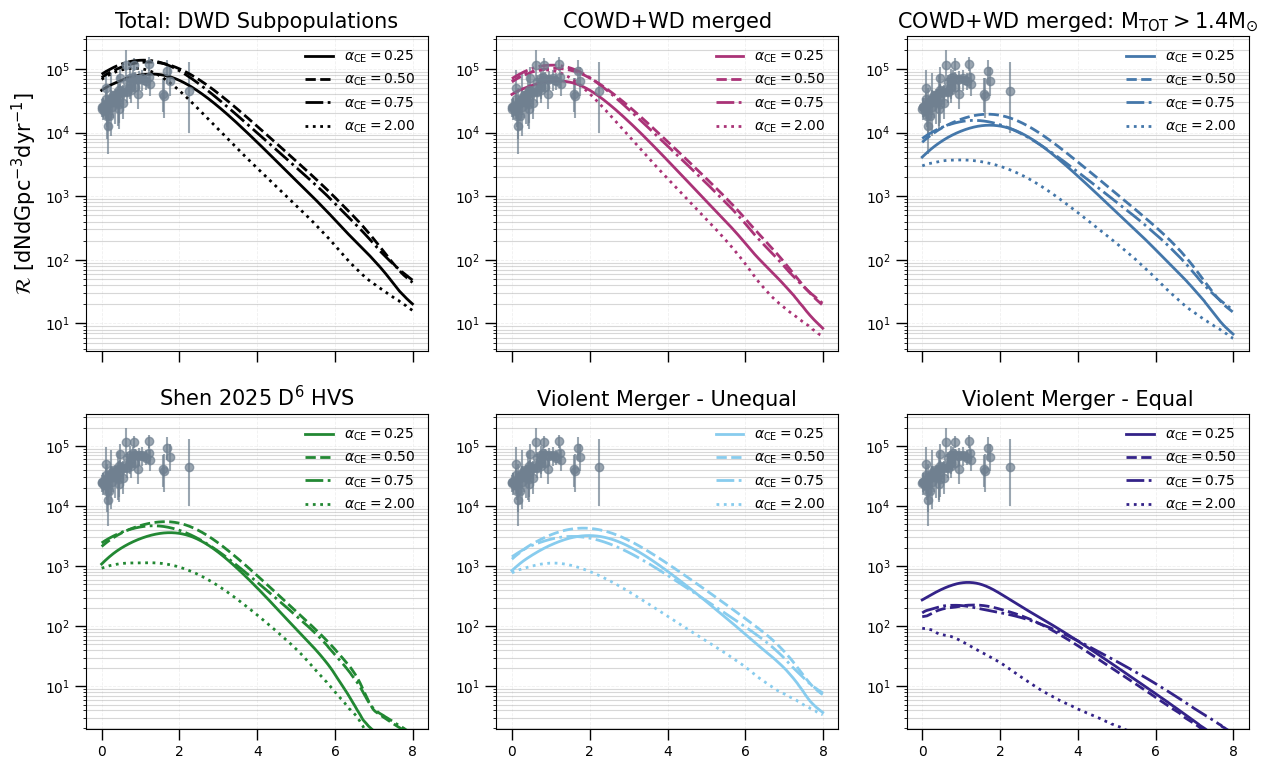

In [22]:
# let's make the plot with just the WDWD progenitor systems

# plotting formation efficencies

fig, ax = plt.subplots(
    2, 3,
    sharex=True,
    figsize=(15, 9))
    #gridspec_kw={"height_ratios": [1, 3, 1, 3]}

cset_mu = tc.muted
cset_br = tc.bright

### TOT Subpop

# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax[0,0].errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'slategrey', alpha=0.7)#,label='Briel et al. 2023')

ax[0,0].plot(redshifts_025[1], rates_025[6], linewidth=2,color='black',label=r"$\alpha_{\mathrm{CE}}=0.25$")
ax[0,0].plot(redshifts_05[1], rates_05[6], linewidth=2,color='black', ls="--",label=r"$\alpha_{\mathrm{CE}}=0.50$")
ax[0,0].plot(redshifts_075[1], rates_075[6], linewidth=2,color='black',ls="-.",label=r"$\alpha_{\mathrm{CE}}=0.75$")
ax[0,0].plot(redshifts_2[1], rates_2[6], linewidth=2,color='black',ls=":",label=r"$\alpha_{\mathrm{CE}}=2.00$")


ax[0,0].set_yscale('log')
ax[0,0].set_ylabel(r"$\mathcal{R}$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=15)
ax[0,0].tick_params(axis='x', length=8, width=1, labelsize=10)
ax[0,0].tick_params(axis='y', length=8, width=1, labelsize=10)
ax[0,0].legend(fontsize=10, frameon=False)
ax[0,0].set_title(r"Total: DWD Subpopulations", fontsize=15)
ax[0,0].grid(True, color='#e0e0e0', linestyle='--', linewidth=0.6, alpha=0.5)
ax[0,0].yaxis.grid(True, which='minor',alpha=0.5)
ax[0,0].xaxis.grid(True, which='minor', alpha=0.5)




### COWD + WD
# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax[0,1].errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'slategrey', alpha=0.7)#,label='Briel et al. 2023')

# ax.fill_between(redshifts_025[1], percentiles_025[1][0], percentiles_025[1][2], alpha = 0.3, color = 'royalblue')
# ax.plot(redshifts_025[1], percentiles_025[1][1],linewidth=1,color='mediumpurple', ls="--", alpha=0.7)#,label='WDWD rate bootstrapped median')
ax[0,1].plot(redshifts_025[1], rates_025[1], linewidth=2,color=cset_br.purple,label=r"$\alpha_{\mathrm{CE}}=0.25$")
ax[0,1].plot(redshifts_05[1], rates_05[1], linewidth=2,color=cset_br.purple, ls="--",label=r"$\alpha_{\mathrm{CE}}=0.50$")
ax[0,1].plot(redshifts_075[1], rates_075[1], linewidth=2,color=cset_br.purple,ls="-.",label=r"$\alpha_{\mathrm{CE}}=0.75$")
ax[0,1].plot(redshifts_2[1], rates_2[1], linewidth=2,color=cset_br.purple,ls=":",label=r"$\alpha_{\mathrm{CE}}=2.00$")


ax[0,1].set_yscale('log')
ax[0,1].tick_params(axis='x', length=8, width=1, labelsize=10)
ax[0,1].tick_params(axis='y', length=8, width=1, labelsize=10)
ax[0,1].legend(fontsize=10, frameon=False)
ax[0,1].set_title(r"COWD+WD merged", fontsize=15)
ax[0,1].grid(True, color='#e0e0e0', linestyle='--', linewidth=0.6, alpha=0.5)
ax[0,1].yaxis.grid(True, which='minor',alpha=0.5)
ax[0,1].xaxis.grid(True, which='minor', alpha=0.5)


# ax[1,1].annotate("SN Ia Observations", xy=(1.25, 1.5*10**5), xytext=(2, 10**5), fontsize=12, color = 'slategrey', arrowprops=dict(facecolor='slategrey', alpha=0.7,arrowstyle='->'))
# ax[1,1].annotate("LVK Observations", xy=(0.22, 10), xytext=(0.7, 8), fontsize=12, color='grey', arrowprops=dict(facecolor='slategrey', alpha=0.7,arrowstyle='->'))





### COWD + WD : M_tot > 1.4

# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax[0,2].errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'slategrey', alpha=0.7)#,label='Briel et al. 2023')

ax[0,2].plot(redshifts_025[1], rates_025[2], linewidth=2,color=cset_br.blue,label=r"$\alpha_{\mathrm{CE}}=0.25$")
ax[0,2].plot(redshifts_05[1], rates_05[2], linewidth=2,color=cset_br.blue, ls="--",label=r"$\alpha_{\mathrm{CE}}=0.50$")
ax[0,2].plot(redshifts_075[1], rates_075[2], linewidth=2,color=cset_br.blue, ls="-.",label=r"$\alpha_{\mathrm{CE}}=0.75$")
ax[0,2].plot(redshifts_2[1], rates_2[2], linewidth=2,color=cset_br.blue, ls=":", label=r"$\alpha_{\mathrm{CE}}=2.00$")


ax[0,2].set_yscale('log')
ax[0,2].tick_params(axis='x', length=8, width=1, labelsize=10)
ax[0,2].tick_params(axis='y', length=8, width=1, labelsize=10)
ax[0,2].legend(fontsize=10, frameon=False)
ax[0,2].set_title(r'COWD+WD merged: $\rm{M_{TOT}}>1.4\rm{M_{\odot}}$', fontsize=15)
ax[0,2].grid(True, color='#e0e0e0', linestyle='--', linewidth=0.6, alpha=0.5)
ax[0,2].yaxis.grid(True, which='minor',alpha=0.5)
ax[0,2].xaxis.grid(True, which='minor', alpha=0.5)




### HVS
# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax[1,0].errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'slategrey', alpha=0.7)#,label='Briel et al. 2023')

# HVS
ax[1,0].plot(redshifts_025[1], rates_025[5], linewidth=2,color=cset_br.green,label=r"$\alpha_{\mathrm{CE}}=0.25$")
ax[1,0].plot(redshifts_05[1], rates_05[5], linewidth=2,color=cset_br.green, ls="--",label=r"$\alpha_{\mathrm{CE}}=0.50$")
ax[1,0].plot(redshifts_075[1], rates_075[5], linewidth=2,color=cset_br.green, ls="-.",label=r"$\alpha_{\mathrm{CE}}=0.75$")
ax[1,0].plot(redshifts_2[1], rates_2[5], linewidth=2,color=cset_br.green, ls=":",label=r"$\alpha_{\mathrm{CE}}=2.00$")


ax[1,0].set_yscale('log')
ax[1,0].tick_params(axis='x', length=8, width=1, labelsize=10)
ax[1,0].tick_params(axis='y', length=8, width=1, labelsize=10)
ax[1,0].legend(fontsize=10, frameon=False)
ax[1,0].set_title('Shen 2025 $\mathrm{D^6}$ HVS', fontsize=15)
ax[1,0].grid(True, color='#e0e0e0', linestyle='--', linewidth=0.6, alpha=0.5)
ax[1,0].yaxis.grid(True, which='minor',alpha=0.5)
ax[1,0].xaxis.grid(True, which='minor', alpha=0.5)



### Unequal Merger
# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax[1,1].errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'slategrey', alpha=0.7)#,label='Briel et al. 2023')

ax[1,1].plot(redshifts_025[1], rates_025[3], linewidth=2,color=cset_mu.cyan,label=r"$\alpha_{\mathrm{CE}}=0.25$")
ax[1,1].plot(redshifts_05[1], rates_05[3], linewidth=2,color=cset_mu.cyan,ls="--",label=r"$\alpha_{\mathrm{CE}}=0.50$")
ax[1,1].plot(redshifts_075[1], rates_075[3], linewidth=2,color=cset_mu.cyan, ls="-.",label=r"$\alpha_{\mathrm{CE}}=0.75$")
ax[1,1].plot(redshifts_2[1], rates_2[3], linewidth=2,color=cset_mu.cyan,ls=":",label=r"$\alpha_{\mathrm{CE}}=2.00$")


ax[1,1].set_yscale('log')
ax[1,1].tick_params(axis='x', length=8, width=1, labelsize=10)
ax[1,1].tick_params(axis='y', length=8, width=1, labelsize=10)
ax[1,1].legend(fontsize=10, frameon=False)
ax[1,1].set_title('Violent Merger - Unequal', fontsize=15)
ax[1,1].grid(True, color='#e0e0e0', linestyle='--', linewidth=0.6, alpha=0.5)
ax[1,1].yaxis.grid(True, which='minor',alpha=0.5)
ax[1,1].xaxis.grid(True, which='minor', alpha=0.5)


### Equal Merger
# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax[1,2].errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'slategrey', alpha=0.7)#,label='Briel et al. 2023')

ax[1,2].plot(redshifts_025[1], rates_025[4], linewidth=2,color=cset_mu.indigo,label=r"$\alpha_{\mathrm{CE}}=0.25$")
ax[1,2].plot(redshifts_05[1], rates_05[4], linewidth=2,color=cset_mu.indigo, ls="--", label=r"$\alpha_{\mathrm{CE}}=0.50$")
ax[1,2].plot(redshifts_075[1], rates_075[4], linewidth=2,color=cset_mu.indigo, ls="-.", label=r"$\alpha_{\mathrm{CE}}=0.75$")
ax[1,2].plot(redshifts_2[1], rates_2[4], linewidth=2,color=cset_mu.indigo, ls=":",label=r"$\alpha_{\mathrm{CE}}=2.00$")

ax[1,2].set_yscale('log')
ax[1,2].tick_params(axis='x', length=8, width=1, labelsize=10)
ax[1,2].tick_params(axis='y', length=8, width=1, labelsize=10)
ax[1,2].legend(fontsize=10, frameon=False)
ax[1,2].set_title('Violent Merger - Equal', fontsize=15)
ax[1,2].grid(True, color='#e0e0e0', linestyle='--', linewidth=0.6, alpha=0.5)
ax[1,2].yaxis.grid(True, which='minor',alpha=0.5)
ax[1,2].xaxis.grid(True, which='minor', alpha=0.5)


# # make the ylabel shared so easier to comapre
ax[0,0].sharey(ax[0,1])
ax[0,2].sharey(ax[0,0])
ax[1,0].sharey(ax[1,1])
ax[1,2].sharey(ax[1,0])

# plt.subplots_adjust(hspace=0.35)

# save figure:
# plt.savefig("../figures/rates_redshift_variations_subplots.png",bbox_inches='tight',pad_inches=0.1)

### Let's look at the number of NSNS systems (make sure these are optimized runs)